# Installs

<li>pip install mne<li>
<li>pip install pandas<li>
<li>pip install numpy<li>
<li>pip install torch<li>
<li>pip install torcheeg<li>

In [1]:

import os
import random
import time
from mne.datasets import eegbci
import mne
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt
from sklearn import metrics
from torcheeg import transforms
from collections import Counter
from torcheeg.model_selection import KFold
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split


In [2]:
edffiles=r"C:\Users\johan\Documents\Documents\School\advanced machine learning\PROJECT\BCI"
subjects_id=np.arange(1,5)
runs_id=np.arange(4,10)
paths=eegbci.load_data(subjects=subjects_id, runs=runs_id,path=edffiles, update_path=True)
paths

c:\Users\johan\Documents\Documents\School\advanced machine learning\torcheeg-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R05.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R07.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R09.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/

# Check cuda is available


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [4]:
edffile=r'C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S003/S003R03.edf'


raw=mne.io.read_raw_edf(edffile)
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [5]:
print("duration: ",raw.annotations.duration)
print("count: ",raw.annotations.count())
print("onset:  ",raw.annotations.onset)
print("channel names: ",raw.ch_names)
raw.annotations.to_data_frame()


duration:  [4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1
 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1]
count:  {'T0': 15, 'T1': 7, 'T2': 8}
onset:   [  0.    4.2   8.3  12.5  16.6  20.8  24.9  29.1  33.2  37.4  41.5  45.7
  49.8  54.   58.1  62.3  66.4  70.6  74.7  78.9  83.   87.2  91.3  95.5
  99.6 103.8 107.9 112.1 116.2 120.4]
channel names:  ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


,onset,duration,description
0,2009-08-12 16:15:00.000,4.2,T0
1,2009-08-12 16:15:04.200,4.1,T2
2,2009-08-12 16:15:08.300,4.2,T0
3,2009-08-12 16:15:12.500,4.1,T1
4,2009-08-12 16:15:16.600,4.2,T0
5,2009-08-12 16:15:20.800,4.1,T2
6,2009-08-12 16:15:24.900,4.2,T0
7,2009-08-12 16:15:29.100,4.1,T1
8,2009-08-12 16:15:33.200,4.2,T0
9,2009-08-12 16:15:37.400,4.1,T1


In [6]:
events_=mne.events_from_annotations(raw)
counter=0
for i in events_[0]:
    print(f"number is {counter +1}: ",i)
    counter +=1

number is 1:  [0 0 1]
number is 2:  [672   0   3]
number is 3:  [1328    0    1]
number is 4:  [2000    0    2]
number is 5:  [2656    0    1]
number is 6:  [3328    0    3]
number is 7:  [3984    0    1]
number is 8:  [4656    0    2]
number is 9:  [5312    0    1]
number is 10:  [5984    0    2]
number is 11:  [6640    0    1]
number is 12:  [7312    0    3]
number is 13:  [7968    0    1]
number is 14:  [8640    0    3]
number is 15:  [9296    0    1]
number is 16:  [9968    0    2]
number is 17:  [10624     0     1]
number is 18:  [11296     0     2]
number is 19:  [11952     0     1]
number is 20:  [12624     0     3]
number is 21:  [13280     0     1]
number is 22:  [13952     0     2]
number is 23:  [14608     0     1]
number is 24:  [15280     0     3]
number is 25:  [15936     0     1]
number is 26:  [16608     0     3]
number is 27:  [17264     0     1]
number is 28:  [17936     0     2]
number is 29:  [18592     0     1]
number is 30:  [19264     0     3]


In [7]:
def get_X_y(path: str, movement: str )-> tuple[list,list]:
    raw_data=mne.io.read_raw_edf(path)
    durations=raw.annotations.duration
    onset=raw.annotations.onset
    events_=mne.events_from_annotations(raw_data)
    tasks={}
    X=[]
    y=[]
    counter=0
    match movement:
        case 'lr':
            tasks={1:8, 2:0, 3:1}
            
        case 'ilr':
            tasks={1:8, 2:2, 3:3}
        case 'ff':
            tasks={1:8, 2:4, 3:5}
        case 'iff':
            tasks={1:8, 2:6, 3:7}
        case _:

            raise ValueError(f"movement: {movement} is not supported. Chose either lr, ilr, ff or iff")
    
    for e,o,d in zip(events_[0],onset,durations):
        X.append(raw_data.get_data(start=int ( o * 160), stop= int (( d * 160) + ( o * 160))))
        y.append(e[2])
        counter+=1

    y=list(map(lambda x: tasks[x], y))
    
    return X, y



In [8]:
def remove_base_state(X,y):
    X_temp=[]
    y_temp=[]
    for i,j in zip(X,y):
        if j!= 8:
            X_temp.append(i)
            y_temp.append(j)

    return X_temp, y_temp




In [9]:
edffiles=r"C:\Users\johan\Documents\Documents\School\advanced machine learning\PROJECT\BCI"
lr=[3,7,11]
ilr=[4,8,12]
ff=[5,9,13]
iff=[6,10,14]
movements=[lr,ilr,ff,iff]
mov_str=['lr','ilr','ff','iff']
X=[]
y=[]
for m,sr in zip(movements,mov_str):
    paths=eegbci.load_data(subjects=[1], runs=m,path=edffiles, update_path=True)
    for path in paths:
        Xs,ys=get_X_y(path,sr)
        X.extend(Xs)
        y.extend(ys)

X,y=remove_base_state(X,y)

### Normalize

In [10]:

for i in range (len(X)):
    mean=np.mean(X[i],axis=1,keepdims=True) 
    std=np.std(X[i],axis=1,keepdims=True)
    X[i]=(X[i]-mean)/std





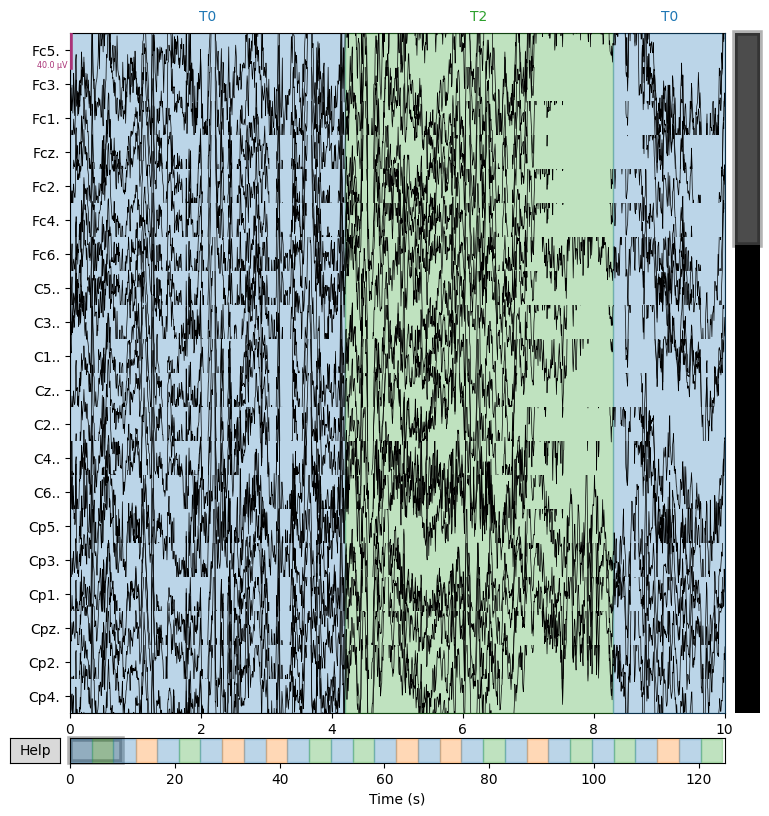

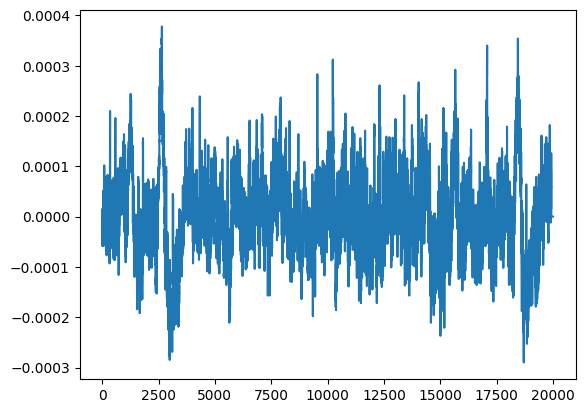

In [11]:
raw.plot(show_options=True)
first_ch=raw[0][0]
first_ch
plt.plot(first_ch[0])
plt.show()


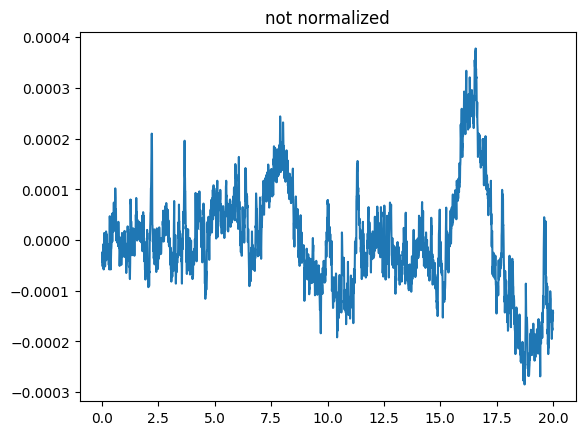

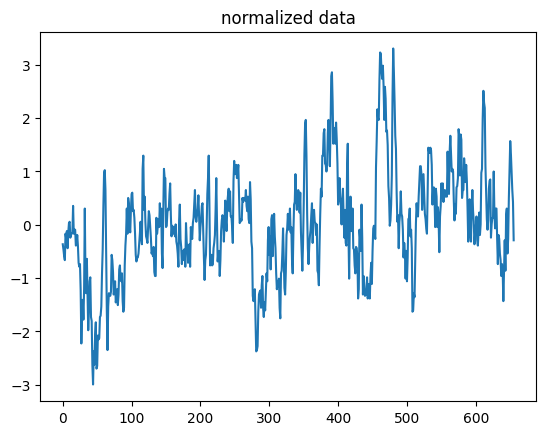

In [12]:
data=raw.get_data()
ch_1=data[0]

hs=160
n=np.arange(1, 3201)
n=n/hs # set seconds
plt.plot(n,ch_1[:3200]) # first 20 seconds = 160 X 20
plt.title("not normalized")
plt.show()

plt.plot(X[0][0][:3200])
plt.title("normalized data")
plt.show()

In [13]:
#treatment of unequal sized tensors

counter=1
zeros=np.zeros((64,16)) #padding with zeros so all segments are of same size
for i in range(len(X)):
    if i%2 ==0:
        X[i]=X[i][:,:656]
        mean=mean+X[i]
        counter+=1
    
mean=mean/counter
print(mean)
print(X[1].shape)
print(X[0].shape)


[[-0.07286116 -0.07014245 -0.02371409 ...  0.14907582  0.07934221
   0.03687196]
 [-0.04515183 -0.02544004  0.00982835 ...  0.15259464  0.101004
   0.02877336]
 [-0.02600162  0.00143524  0.03485571 ...  0.18825602  0.14231337
   0.07307112]
 ...
 [-0.14095948 -0.1711365  -0.18271357 ...  0.15373024  0.05291335
  -0.01388662]
 [-0.13867663 -0.1745767  -0.1989144  ...  0.1400953   0.05052715
   0.00501884]
 [-0.07382805 -0.14069894 -0.19270226 ...  0.24164538  0.07379136
  -0.00576252]]
(64, 656)
(64, 656)


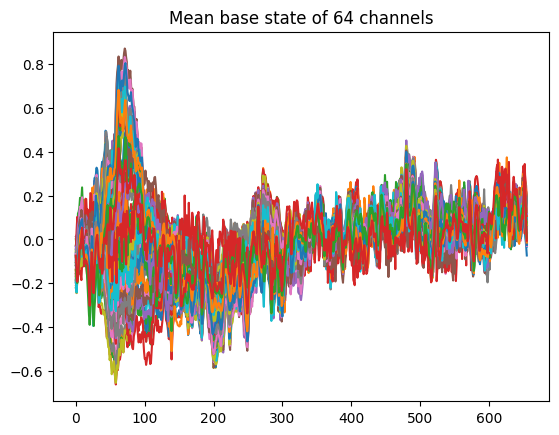

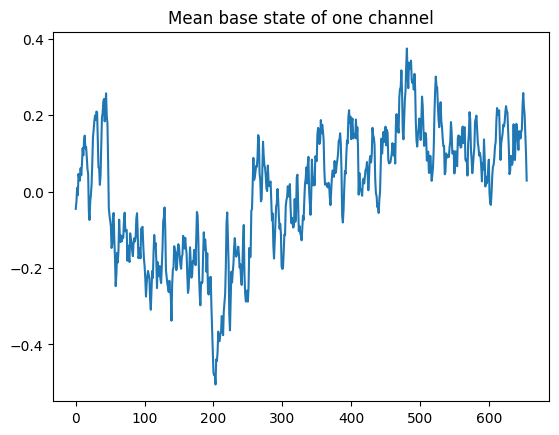

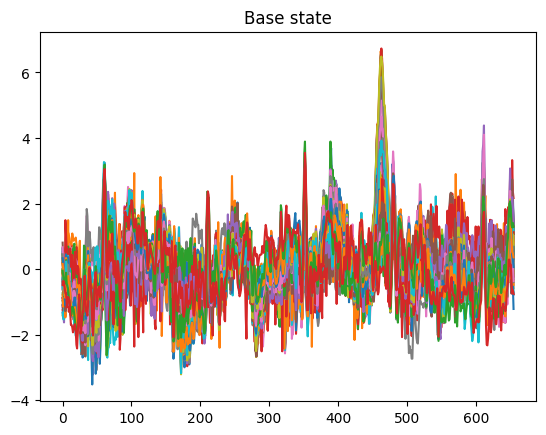

In [14]:
plt.plot(mean.T)
plt.title("Mean base state of 64 channels")
plt.show()
plt.plot(mean[1])
plt.title("Mean base state of one channel")
plt.show()
plt.plot(X[0].T)
plt.title("Base state")
plt.show()


In [15]:
def split_and_convert(X,y,unsqueeze=False):
    X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42)

    X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42)

    X_train=torch.tensor(X_train,dtype=torch.float32)
    y_train=torch.tensor(y_train,dtype=torch.long)

    X_val=torch.tensor(X_val,dtype=torch.float32)
    y_val=torch.tensor(y_val,dtype=torch.long)

    X_test=torch.tensor(X_test,dtype=torch.float32)
    y_test=torch.tensor(y_test,dtype=torch.long)
    if unsqueeze==True:
        X_train=X_train.unsqueeze(1)
        X_val=X_val.unsqueeze(1)
        X_test=X_test.unsqueeze(1)
    return X_train, y_train, X_val, y_val, X_test, y_test

In [16]:

X_train_1D, y_train,X_val_1D, y_val,X_test_1D,y_test=split_and_convert(X,y)

X_train_2D, y_train,X_val_2D, y_val,X_test_2D,y_test=split_and_convert(X,y,unsqueeze=True)


print(X_train_2D.shape)
print(X_val_2D.shape)
print(X_test_2D.shape)



C:\Users\johan\AppData\Local\Temp\ipykernel_22248\4095976798.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X_train=torch.tensor(X_train,dtype=torch.float32)


torch.Size([126, 1, 64, 656])
torch.Size([27, 1, 64, 656])
torch.Size([27, 1, 64, 656])


In [17]:
#1D dataloaders
training_dataset_1D=TensorDataset(X_train_1D,y_train)
val_dataset_1D=TensorDataset(X_val_1D,y_val)
test_dataset_1D=TensorDataset(X_test_1D,y_test)
train_loader_1D = DataLoader(training_dataset_1D, batch_size=30, shuffle=True,generator=torch.Generator().manual_seed(42))
val_loader_1D = DataLoader(val_dataset_1D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))
test_loader_1D = DataLoader(test_dataset_1D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))

#2D dataloaders
training_dataset_2D=TensorDataset(X_train_2D,y_train)
val_dataset_2D=TensorDataset(X_val_2D,y_val)
test_dataset_2D=TensorDataset(X_test_2D,y_test)
train_loader_2D = DataLoader(training_dataset_2D, batch_size=30, shuffle=True,generator=torch.Generator().manual_seed(42))
val_loader_2D = DataLoader(val_dataset_2D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))
test_loader_2D = DataLoader(test_dataset_2D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))



In [18]:

class eggNetWork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv2d= nn.Sequential(
            #block1
            nn.Conv2d(1,16,(1,40),padding=10),
            nn.BatchNorm2d(16),
            nn.ELU(),
            

            #block2
            nn.Conv2d(16,32,(64,3),padding=10),
            nn.BatchNorm2d(32),
            nn.ELU(),
           

            #block3
            nn.Conv2d(32,64,(20,20),padding=10),
            nn.ELU(),
            nn.BatchNorm2d(64),
            

            nn.AdaptiveAvgPool2d(2),
            nn.Flatten()  
        )

        self.conv1d= nn.Sequential(
            #block1
            nn.Conv1d(64,128,40,padding=40),
            nn.MaxPool1d(2,stride=2),
            nn.ELU(),
            nn.BatchNorm1d(128),

            #block2
            nn.Conv1d(128,256,10,padding=10),
            nn.MaxPool1d(10,stride=2),
            nn.ELU(),
            nn.BatchNorm1d(256),

             #block3
            nn.Conv1d(256,128,10,padding=10),
            nn.MaxPool1d(10,stride=2),
            nn.ELU(),
            nn.BatchNorm1d(128),

            #block4
            nn.Conv1d(128,40,10,padding=10),
            nn.MaxPool1d(10,stride=2),
            nn.ELU(),
            nn.BatchNorm1d(40),

            #block5
            nn.Conv1d(40,20,20,padding=20),
            nn.ELU(),
            nn.BatchNorm1d(20), 

            #block6
            nn.Conv1d(20,10,20,padding=20),
            nn.ELU(),
            nn.BatchNorm1d(10), 

            #block7
            nn.Conv1d(10,5,20,padding=20),
            nn.ELU(),
            nn.BatchNorm1d(5),


            nn.AdaptiveAvgPool1d(64),
            nn.Flatten()
        )

        self.fc=nn.Sequential(
            nn.Linear(320+64*2*2, 9),
            
            

        )

        

    def forward(self, x1d,x2d):
        conv1d=self.conv1d(x1d)
        conv2d=self.conv2d(x2d)
        x=torch.cat((conv1d,conv2d),dim=1)
        out=self.fc(x)
        return out


In [19]:
module=eggNetWork()
criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(module.parameters(), lr=0.005, momentum=0.9)


In [20]:
def criterion_w_weights(y):
    num_classes = 9

    class_counts = torch.bincount(y, minlength=num_classes)
    class_weights = 1.0 / class_counts.float()
    class_weights = class_weights / class_weights.sum() * num_classes

    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    return criterion

In [21]:
def training_and_evaluation(module ,device,opt ,train_loader_1D,train_loader_2D,val_loader_1D,val_loader_2D):
    
    

    module.train()
    total_loss=0
    val_loss=0
    for (X1,y1),(X2,y2) in zip(train_loader_1D,train_loader_2D):
        #criterion=criterion_w_weights(y2)

        X1, X2, y1, y2=X1.to(device), X2.to(device), y1.to(device), y2.to(device)
        optimizer.zero_grad() #rest the greadient
        
        pred=module(X1,X2) 
        loss=criterion(pred,y1)
        loss.backward()
        opt.step()
        avrg_batch_loss=loss.item()
        total_loss+=loss.item()
    
    print(f"total_loss: {total_loss}")

    module.eval()
    with torch.no_grad():
        print("evaluation")
        counter=0
        all_pred=[]
        for (X1,y1),(X2,y2) in zip(val_loader_1D,val_loader_2D):
            #criterion=criterion_w_weights(y2)
            X1, X2, y1, y2=X1.to(device), X2.to(device), y1.to(device), y2.to(device)
            pred=module(X1,X2)
            
            loss=criterion(pred,y1)
            
            val_loss+=loss.item()
            counter+=1
            predictions=pred.argmax(axis=1)
            all_pred.extend([int(v) for v in predictions])
            
        print(f"val_loss: {val_loss}")
        print(f"prediction distribution:{Counter(all_pred)}")
        print(f"logits: {pred}")


    print("Finnished training")
        
        

In [22]:
def testing(module,device, test_loader_1D,test_loader_2D):
    module.eval()
    total_loss=0
    correct=0
    total=0
    with torch.no_grad():
        for (X1,y1),(X2,y2) in zip(test_loader_1D,test_loader_2D):
            #criterion=criterion_w_weights(y2)
            X1, X2, y1, y2=X1.to(device), X2.to(device), y1.to(device), y2.to(device)
            pred=module(X1,X2)
            
            loss=criterion(pred,y1)
            total_loss+=loss.item()
            _,indices=torch.max(pred,1)
            correct+=(indices==y1).sum().item()
            total+=len(y1)
        print(100*(correct/total))

    

In [23]:
epoch=2
for i in range(epoch):
    training_and_evaluation(module=module,device=device,opt=optimizer ,train_loader_1D=train_loader_1D,train_loader_2D=train_loader_2D,val_loader_1D=val_loader_1D,val_loader_2D=val_loader_2D)

total_loss: 10.652664184570312
evaluation
val_loss: 2.1812703609466553
prediction distribution:Counter({3: 15, 0: 6, 4: 4, 6: 1, 7: 1})
logits: tensor([[-5.0712e-02, -8.9765e-02,  1.3230e-02,  9.6301e-02,  2.2350e-02,
          4.7052e-02, -3.5090e-02,  6.3202e-02, -9.8493e-02],
        [ 2.0597e-01, -2.3817e-02,  1.0755e-03, -1.3697e-01,  5.1450e-02,
         -7.7586e-02, -3.9109e-02, -1.4724e-01, -1.2568e-02],
        [-3.5802e-02,  3.1965e-02, -1.1423e-01,  3.5999e-02,  6.5441e-02,
         -2.5121e-02,  5.3011e-03, -8.7197e-02, -6.1182e-02],
        [ 4.6649e-02,  1.9361e-02,  7.5354e-03,  9.8708e-02, -1.9758e-01,
          3.2788e-02, -1.3537e-01,  3.8392e-03, -9.2161e-02],
        [ 1.9196e-01, -3.8905e-02,  4.2249e-02, -2.3617e-01,  3.2772e-02,
         -2.0717e-01,  4.3683e-02, -1.9471e-01, -4.0816e-02],
        [ 4.8267e-04, -3.9138e-02, -4.5453e-02,  1.0637e-01,  1.0211e-02,
         -3.3328e-02, -6.1401e-02,  2.4208e-02, -2.6882e-02],
        [ 2.1523e-01,  1.5302e-01, -1.21

In [24]:
testing(module,device=device,test_loader_1D=test_loader_1D,test_loader_2D=test_loader_2D)

29.629629629629626
